Generated 21 new signed graph(s):

Graph 1: Added (1, 5)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (1, 5)]
  Negative Edges: [(7, 8)]

Graph 2: Added (1, 6)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (1, 6)]
  Negative Edges: [(7, 8)]

Graph 3: Added (1, 7)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (1, 7)]
  Negative Edges: [(7, 8)]

Graph 4: Added (1, 8)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (1, 8)]
  Negative Edges: [(7, 8)]

Graph 5: Added (2, 3)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (2, 3)]
  Negative Edges: [(7, 8)]

Graph 6: Added (2, 4)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (2, 4)]
  Negative Edges: [(7, 8)]

Graph 7: Added (2, 6)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (2, 6)]
  Negative Edges: [(7, 8)]

Graph 8: Added (2, 7)
  Positive Edges: [(1, 4), (4, 7), (1, 2), (2, 5), (1, 3), (3, 6), (

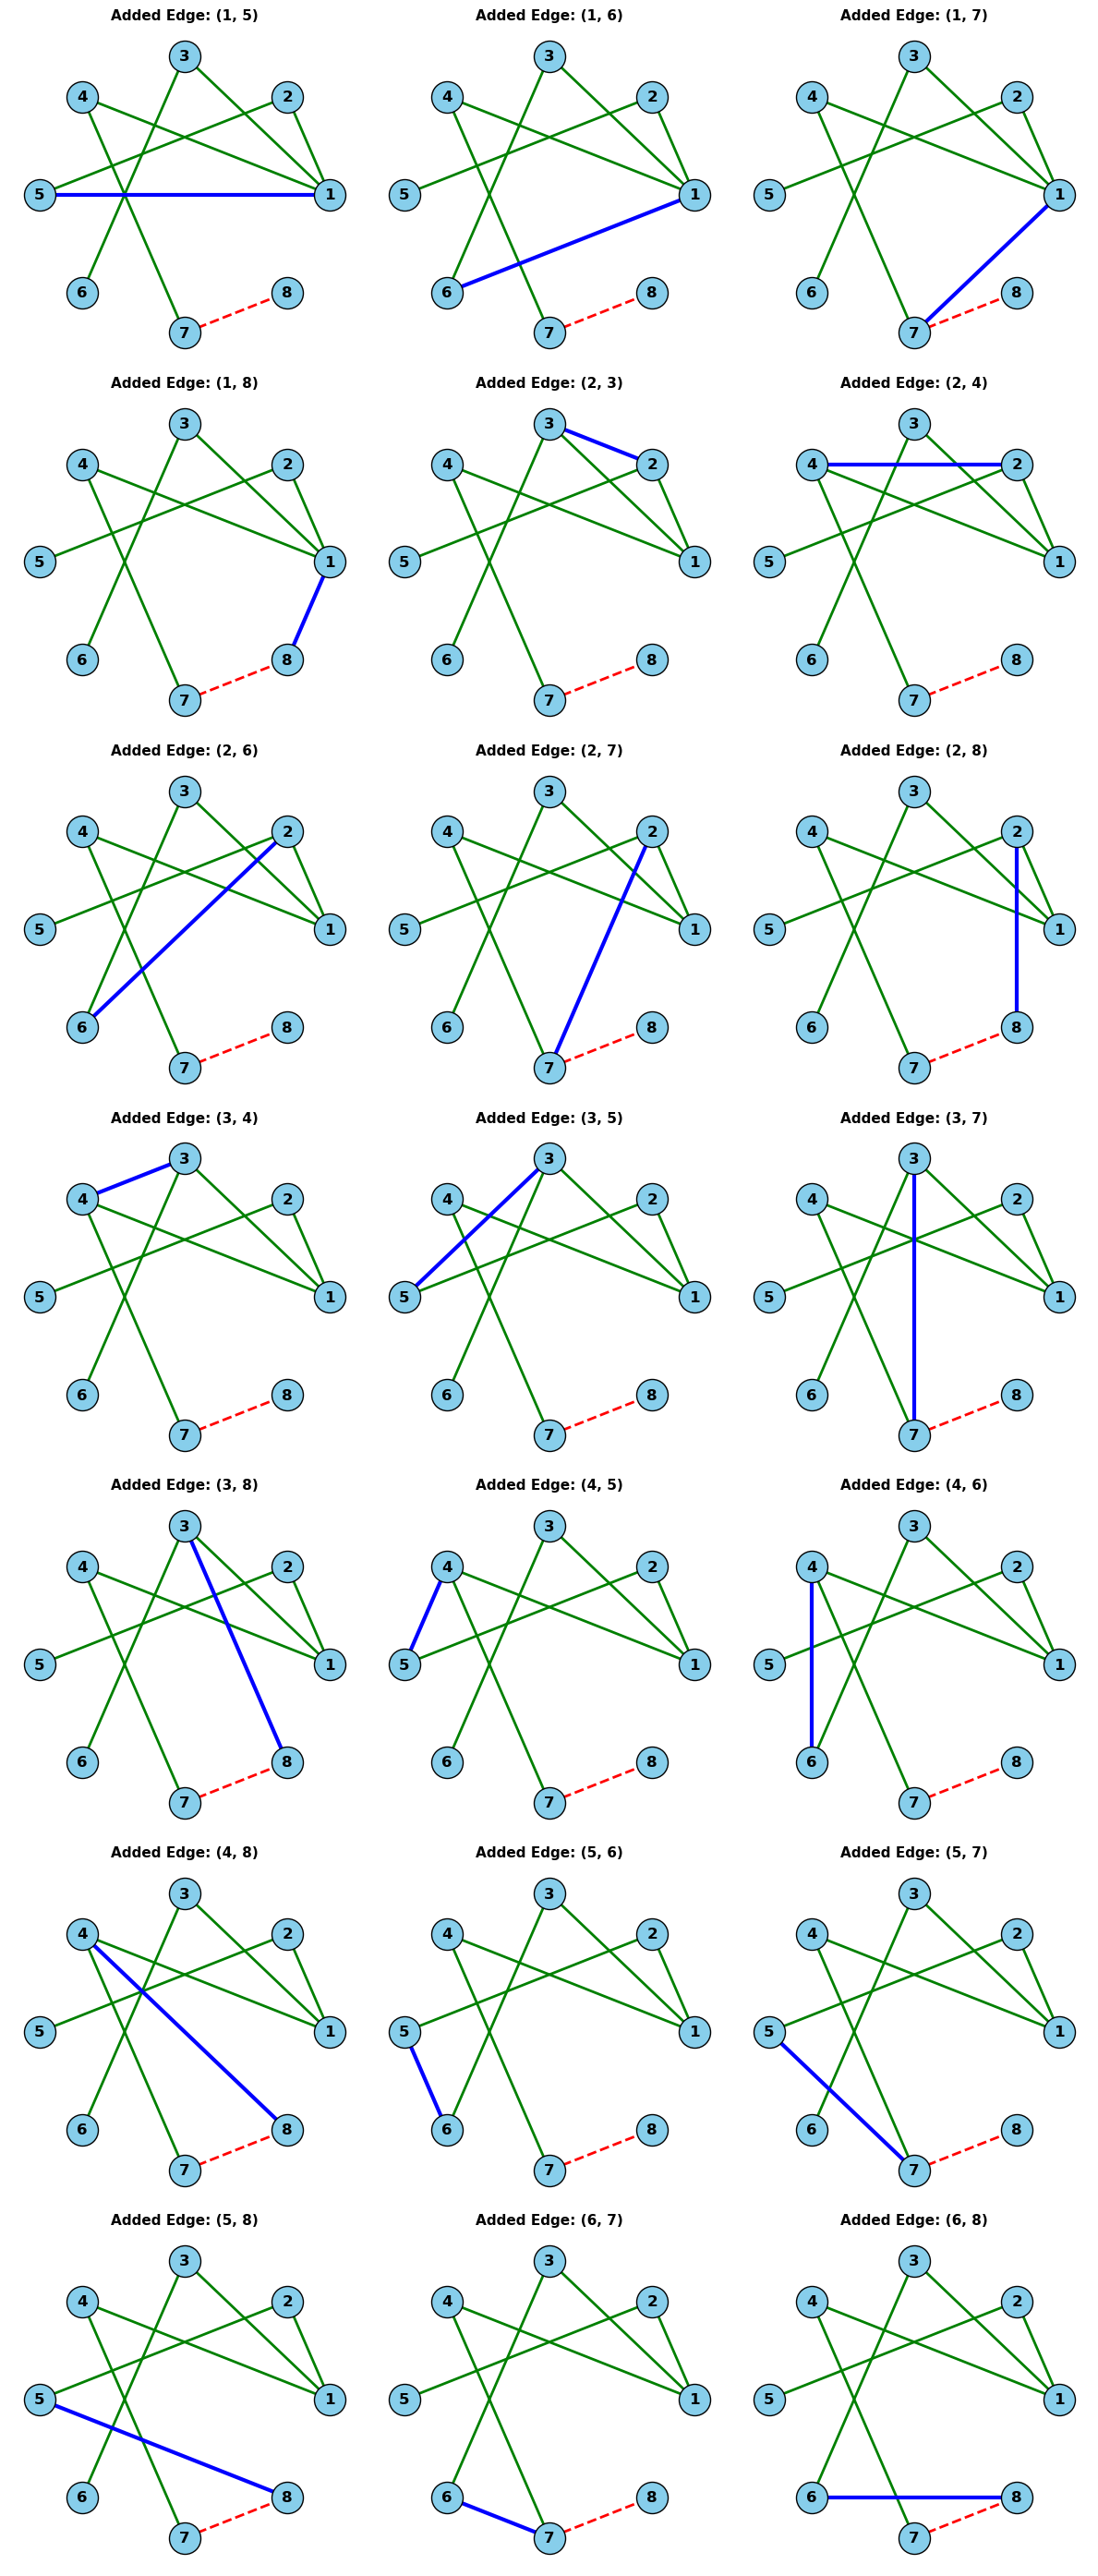

In [6]:
import itertools
import matplotlib.pyplot as plt
import networkx as nx


def generate_augmented_signed_graphs(num_vertices, pos_edges, neg_edges):
    """Finds all non-adjacent pairs in the input signed graph and creates a new graph

    for each pair by adding a positive edge between them.

    Parameters:
    - num_vertices (int): Total number of vertices (labeled 1 to N).
    - pos_edges (list of tuples): Existing positive edges.
    - neg_edges (list of tuples): Existing negative edges.

    Returns:
    - graph_collection (list of dicts): Collection of augmented signed graphs.
    """
    # Standardize all existing edges into sorted tuples to handle undirected lookup
    existing_edges = set()
    for u, v in pos_edges + neg_edges:
        existing_edges.add(tuple(sorted((u, v))))

    # Identify all pairs of non-adjacent vertices
    all_vertices = list(range(1, num_vertices + 1))
    non_adjacent_pairs = []

    for u, v in itertools.combinations(all_vertices, 2):
        if tuple(sorted((u, v))) not in existing_edges:
            non_adjacent_pairs.append((u, v))

    # Generate a new graph dictionary for each non-adjacent pair
    graph_collection = []
    for u, v in non_adjacent_pairs:
        graph_collection.append(
            {
                "added_edge": (u, v),
                "pos_edges": pos_edges + [(u, v)],
                "neg_edges": list(neg_edges),
            }
        )

    return graph_collection


def plot_signed_graph_collection(num_vertices, graph_collection):
    """Plots all generated signed graphs in a grid layout, highlighting the new positive edge in blue."""
    num_graphs = len(graph_collection)
    if num_graphs == 0:
        print("No non-adjacent pairs found. The graph is complete.")
        return

    # Calculate grid dimensions for plotting
    cols = min(3, num_graphs)
    rows = (num_graphs + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    # Consistent circular layout for all subplots
    G_base = nx.Graph()
    G_base.add_nodes_from(range(1, num_vertices + 1))
    pos = nx.circular_layout(G_base)

    for idx, g in enumerate(graph_collection, 1):
        G = nx.Graph()
        G.add_nodes_from(range(1, num_vertices + 1))

        plt.subplot(rows, cols, idx)

        # Draw nodes
        nx.draw_networkx_nodes(
            G, pos, node_color="skyblue", node_size=600, edgecolors="black"
        )
        nx.draw_networkx_labels(G, pos, font_weight="bold")

        # Original positive edges (Green, Solid)
        orig_pos = [
            e for e in g["pos_edges"] if tuple(sorted(e)) != tuple(sorted(g["added_edge"]))
        ]
        if orig_pos:
            nx.draw_networkx_edges(
                G, pos, edgelist=orig_pos, style="solid", edge_color="green", width=2
            )

        # Negative edges (Red, Dashed)
        if g["neg_edges"]:
            nx.draw_networkx_edges(
                G, pos, edgelist=g["neg_edges"], style="dashed", edge_color="red", width=2
            )

        # Newly added positive edge (Blue, Solid)
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[g["added_edge"]],
            style="solid",
            edge_color="blue",
            width=3,
        )

        plt.title(f"Added Edge: {g['added_edge']}", fontsize=11, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Example Usage
if __name__ == "__main__":
    # Define input signed graph (5 vertices)
    num_vertices = 8
    positive_edges = [(1, 4), (4, 7), (1, 2), (2,5), (1, 3), (3,6)]
    negative_edges = [(7,8)]

    # 1. Generate collection of new graphs
    collection = generate_augmented_signed_graphs(
        num_vertices, positive_edges, negative_edges
    )

    # 2. Print output structure to terminal
    print(f"Generated {len(collection)} new signed graph(s):\n")
    for i, g in enumerate(collection, 1):
        print(f"Graph {i}: Added {g['added_edge']}")
        print(f"  Positive Edges: {g['pos_edges']}")
        print(f"  Negative Edges: {g['neg_edges']}\n")

    # 3. Display plot grid of all resulting graphs
    plot_signed_graph_collection(num_vertices, collection)